<a href="https://colab.research.google.com/github/lucabarattini/STAT-5703/blob/main/STATS5703_Assignment_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
# Excercise 1:

In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
pd.set_option('display.max_rows', None)

# I added an 'r' before '\s+' to make it a raw string and fix the escape sequence warning
df = pd.read_csv('HW3-1.txt', sep=r'\s+', index_col='Company')
data = df[['Sales', 'Profit', 'Assets']]
n = len(data)

# a) Compute sample mean vector and covariance matrix
mean_vector = data.mean().values
cov_matrix = data.cov().values

print("--- Part a ---")
print("Sample Mean Vector (x-bar):\n", mean_vector)
print("\nSample Covariance Matrix (S):\n", cov_matrix)

--- Part a ---
Sample Mean Vector (x-bar):
 [155.603  14.704 710.911]

Sample Covariance Matrix (S):
 [[ 7.47645325e+03  3.03618620e+02 -3.55759596e+04]
 [ 3.03618620e+02  2.61903156e+01 -1.05382739e+03]
 [-3.55759596e+04 -1.05382739e+03  2.37054270e+05]]


In [ ]:
print("\n--- Part b ---")
# I isolate the 'Sales' and 'Profit' variables specifically based on the dataset
data_2d = df[['Sales', 'Profit']]
mean_2d = data_2d.mean().values
cov_2d = data_2d.cov().values

# I calculate the inverse of the 2D covariance matrix
inv_cov_2d = np.linalg.inv(cov_2d)

# I compute generalized distances for p=2
d2_values_2d = []
for i in range(n):
    x_i = data_2d.iloc[i].values
    diff = x_i - mean_2d
    d2 = np.dot(np.dot(diff.T, inv_cov_2d), diff)
    d2_values_2d.append(d2)

# I find the 50th percentile of Chi-square with df=2
chi2_crit = stats.chi2.ppf(0.5, df=2)

# I calculate the proportion inside the contour
inside_contour = sum(1 for d2 in d2_values_2d if d2 <= chi2_crit)
proportion = inside_contour / n

print(f"Chi-square critical value (df=2, 0.5): {chi2_crit:.4f}")
print(f"Number of observations within 50% contour: {inside_contour} out of {n}")
print(f"Proportion: {proportion:.2f}")


--- Part b ---
Chi-square critical value (df=2, 0.5): 1.3863
Number of observations within 50% contour: 4 out of 10
Proportion: 0.40



--- Part c ---


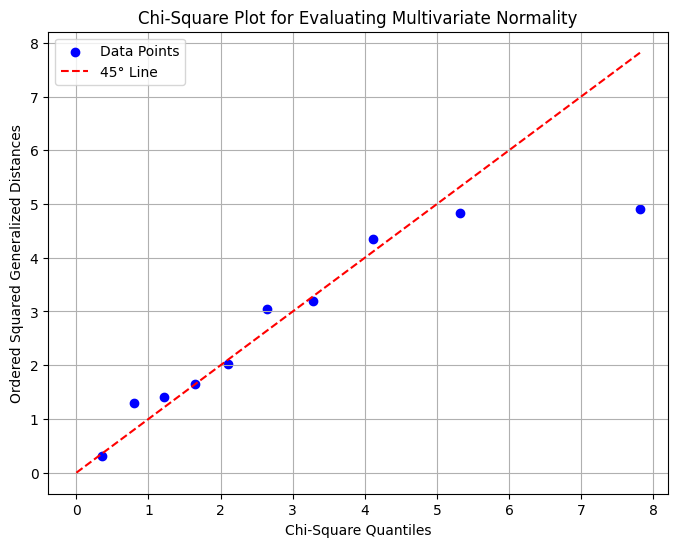

In [ ]:
print("\n--- Part c ---")
# I use the full 3x3 covariance matrix from Part a for 'Sales', 'Profit', and 'Assets'
inv_cov_3d = np.linalg.inv(cov_matrix)

# I compute squared generalized distances for all 3 variables
d2_values_3d = []
for i in range(n):
    x_i = data.iloc[i].values
    diff = x_i - mean_vector
    d2 = np.dot(np.dot(diff.T, inv_cov_3d), diff)
    d2_values_3d.append(d2)

# i. I order the squared distances
d2_sorted = np.sort(d2_values_3d)

# ii. I calculate the theoretical chi-square quantiles
quantiles = []
for i in range(1, n + 1):
    prob = (i - 0.5) / n
    q = stats.chi2.ppf(prob, df=3)
    quantiles.append(q)

# I construct the chi-square scatterplot
plt.figure(figsize=(8, 6))
plt.scatter(quantiles, d2_sorted, color='blue', label='Data Points')

# I plot the 45-degree reference line starting from the origin
max_val = max(max(quantiles), max(d2_sorted))
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', label='45° Line')

plt.title('Chi-Square Plot for Evaluating Multivariate Normality')
plt.xlabel('Chi-Square Quantiles')
plt.ylabel('Ordered Squared Generalized Distances')
plt.legend()
plt.grid(True)
plt.show()

---
# Excercise 2:

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error

# I will run the simulation 1000 times to get stable average results
n_simulations = 1000
n_samples = 100

train_sse_linear_list = []
train_sse_cubic_list = []
test_sse_linear_list = []
test_sse_cubic_list = []

for _ in range(n_simulations):
    # 1. Generate the true linear data
    # X values between -5 and 5
    X = np.random.uniform(-5, 5, n_samples).reshape(-1, 1)

    # True relationship is linear: Y = 3 + 2X + noise
    noise = np.random.normal(0, 2, n_samples).reshape(-1, 1)
    Y = 3 + 2 * X + noise

    # 2. Split into 80% training and 20% test subsets
    X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.20)

    # 3. Fit Model 1 (Linear)
    lin_model = LinearRegression()
    lin_model.fit(X_train, Y_train)

    # Predict and calculate SSE (MSE * number of samples)
    pred_train_lin = lin_model.predict(X_train)
    pred_test_lin = lin_model.predict(X_test)

    train_sse_linear = mean_squared_error(Y_train, pred_train_lin) * len(Y_train)
    test_sse_linear = mean_squared_error(Y_test, pred_test_lin) * len(Y_test)

    # 4. Fit Model 2 (Cubic)
    # Transform X to include X^2 and X^3 terms
    poly = PolynomialFeatures(degree=3, include_bias=False)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    cub_model = LinearRegression()
    cub_model.fit(X_train_poly, Y_train)

    pred_train_cub = cub_model.predict(X_train_poly)
    pred_test_cub = cub_model.predict(X_test_poly)

    train_sse_cubic = mean_squared_error(Y_train, pred_train_cub) * len(Y_train)
    test_sse_cubic = mean_squared_error(Y_test, pred_test_cub) * len(Y_test)

    # 5. Store the results for this loop
    train_sse_linear_list.append(train_sse_linear)
    train_sse_cubic_list.append(train_sse_cubic)
    test_sse_linear_list.append(test_sse_linear)
    test_sse_cubic_list.append(test_sse_cubic)

# Output the average SSE across all simulations
print("--- Average Training SSE ---")
print(f"Model 1 (Linear): {np.mean(train_sse_linear_list):.2f}")
print(f"Model 2 (Cubic):  {np.mean(train_sse_cubic_list):.2f}")
print("-> As predicted, Cubic has the lower Training SSE.\n")

print("--- Average Test SSE ---")
print(f"Model 1 (Linear): {np.mean(test_sse_linear_list):.2f}")
print(f"Model 2 (Cubic):  {np.mean(test_sse_cubic_list):.2f}")
print("-> As predicted, Linear has the lower Test SSE.")

--- Average Training SSE ---
Model 1 (Linear): 310.77
Model 2 (Cubic):  302.91
-> As predicted, Cubic has the lower Training SSE.

--- Average Test SSE ---
Model 1 (Linear): 82.96
Model 2 (Cubic):  85.14
-> As predicted, Linear has the lower Test SSE.


---
# Excercise 3:

In [ ]:
import statsmodels.formula.api as smf

df = pd.read_csv('HW3-house.csv')
n = len(df)

print("--- Part a ---")
# Fit simple linear regression
model_a = smf.ols('price ~ sqft', data=df).fit()
beta_1_a = model_a.params['sqft']

print(f"On average, an extra sqft adds ${beta_1_a:.2f} to the value of a house.")
# print(model_a.summary()) # Uncomment if you want to see the full regression table

--- Part a ---
On average, an extra sqft adds $70.23 to the value of a house.


In [ ]:
print("\n--- Part b ---")
# Get influence metrics from the fitted model
influence = model_a.get_influence()
hat_diagonals = influence.hat_matrix_diag

# Calculate the threshold
p = 1
threshold = 2 * (p + 1) / n

# Find the indices where leverage exceeds the threshold
# Note: df.index represents the row numbers (0 to 127)
high_leverage_indices = df.index[hat_diagonals > threshold].tolist()

print(f"Leverage threshold: {threshold:.5f}")
print(f"Indexes of high-leverage points: {high_leverage_indices}")


--- Part b ---
Leverage threshold: 0.03125
Indexes of high-leverage points: [14, 28, 37, 40, 61, 65, 83, 84, 96, 102, 103, 105]


In [ ]:
print("\n--- Part c ---")
# Fit parallel lines model.
# C(nbhd) tells statsmodels to treat 'nbhd' as categorical and handles dummy vars automatically.
model_c = smf.ols('price ~ sqft + C(nbhd)', data=df).fit()
beta_1_c = model_c.params['sqft']

print(f"In the parallel lines model, an extra sqft adds ${beta_1_c:.2f} on average.")


--- Part c ---
In the parallel lines model, an extra sqft adds $46.39 on average.


In [ ]:
print("\n--- Part e ---")
# Fit non-parallel lines model (interaction model)
# The '*' operator includes both main effects and their interaction
model_e = smf.ols('price ~ sqft * C(nbhd)', data=df).fit()

# Extract coefficients
# Note: Statsmodels names might vary slightly, usually 'sqft', 'sqft:C(nbhd)[T.nbhd02]', etc.
# We will pull them dynamically to be safe.
beta_sqft_base = model_e.params['sqft']
beta_interact_n2 = model_e.params.get('sqft:C(nbhd)[T.nbhd02]', 0)
beta_interact_n3 = model_e.params.get('sqft:C(nbhd)[T.nbhd03]', 0)

slope_n1 = beta_sqft_base
slope_n2 = beta_sqft_base + beta_interact_n2
slope_n3 = beta_sqft_base + beta_interact_n3

print(f"Value added per extra sqft in Neighborhood 1: ${slope_n1:.2f}")
print(f"Value added per extra sqft in Neighborhood 2: ${slope_n2:.2f}")
print(f"Value added per extra sqft in Neighborhood 3: ${slope_n3:.2f}")


--- Part e ---
Value added per extra sqft in Neighborhood 1: $40.30
Value added per extra sqft in Neighborhood 2: $49.43
Value added per extra sqft in Neighborhood 3: $49.33


In [ ]:
from statsmodels.stats.anova import anova_lm

print("\n--- Part f ---")
# Perform an ANOVA test comparing the nested models
# model_c is the reduced model (parallel), model_e is the full model (non-parallel)
anova_results = anova_lm(model_c, model_e)
f_stat = anova_results['F'].iloc[1]
p_val = anova_results['Pr(>F)'].iloc[1]

print(f"Partial F-statistic: {f_stat:.4f}")
print(f"P-value: {p_val:.4f}")

if p_val < 0.05:
    print("Conclusion: Reject H0. The non-parallel lines model is significantly different/better.")
else:
    print("Conclusion: Fail to reject H0. The parallel lines model is sufficient; the interaction is not statistically significant.")


--- Part f ---
Partial F-statistic: 0.1976
P-value: 0.8210
Conclusion: Fail to reject H0. The parallel lines model is sufficient; the interaction is not statistically significant.


---
# Excercise IV: